In [32]:
import numpy as np
import pandas as pd
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv(r"E:\Internship_Project\Heart_Disease_Classification\Data_Sets\heart.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Dataset Information

In [34]:
print(f"Number of patients: {len(df)}")
print(f"Number of features: {len(df.columns) - 1}")

df.info()

Number of patients: 1025
Number of features: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### Statistical Summary

In [35]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Percentage

In [37]:
print(
    f"Percentage of heart disease cases: "
    f"{(df['target'].sum() / len(df) * 100):.1f}%"
)

Percentage of heart disease cases: 51.3%


### Ready to X and y

In [38]:
X = df.drop('target', axis=1)
y = df['target']

print("Features:")
print(X.columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

X shape: (1025, 13)
y shape: (1025,)


### Train/Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 717
Testing samples: 308


### Target Distribution

In [40]:
print("Training set:")
print(y_train.value_counts())

print("\nTesting set:")
print(y_test.value_counts())

Training set:
target
1    368
0    349
Name: count, dtype: int64

Testing set:
target
1    158
0    150
Name: count, dtype: int64


### Random Forest Model

In [41]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    min_samples_split=2,
    verbose=1
)

print("Random Forest Parameters")
print("Number of Trees:", rf_classifier.n_estimators)
print("Maximum Depth:", rf_classifier.max_depth)
print("Random State:", rf_classifier.random_state)

Random Forest Parameters
Number of Trees: 100
Maximum Depth: 5
Random State: 42


### Model Training

In [42]:
print("Training the model...")

rf_classifier.fit(X_train, y_train)

print("Model training completed successfully!")

Training the model...
Model training completed successfully!


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


### Prediction 

In [43]:
y_pred = rf_classifier.predict(X_test)

y_pred_proba = rf_classifier.predict_proba(X_test)

print("Prediction completed!")

Prediction completed!


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


### Accuracy

In [44]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9351
Accuracy: 93.51%


### Classification Report

In [45]:
print("Detailed Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No Disease', 'Disease']
    )
)

Detailed Classification Report:

              precision    recall  f1-score   support

  No Disease       0.93      0.94      0.93       150
     Disease       0.94      0.93      0.94       158

    accuracy                           0.94       308
   macro avg       0.93      0.94      0.94       308
weighted avg       0.94      0.94      0.94       308



### Confusion Matrix

In [46]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[141   9]
 [ 11 147]]


In [24]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.9351 (93.51%)


In [25]:
# Detailed classification Report
from ftplib import parse229


print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


Detailed Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.94      0.93       150
     Disease       0.94      0.93      0.94       158

    accuracy                           0.94       308
   macro avg       0.93      0.94      0.94       308
weighted avg       0.94      0.94      0.94       308



In [48]:
# Confusion matrix
print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Confusion Matrix
[[141   9]
 [ 11 147]]


### Precision, Recall, F1 Score

In [49]:
tn, fp, fn, tp = cm.ravel()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = (
    2 * (precision * recall) / (precision + recall)
    if (precision + recall) > 0
    else 0
)

print("Additional Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

Additional Metrics:
Precision: 0.9423
Recall: 0.9304
F1-Score: 0.9363


### Confusion Matrix Visualization

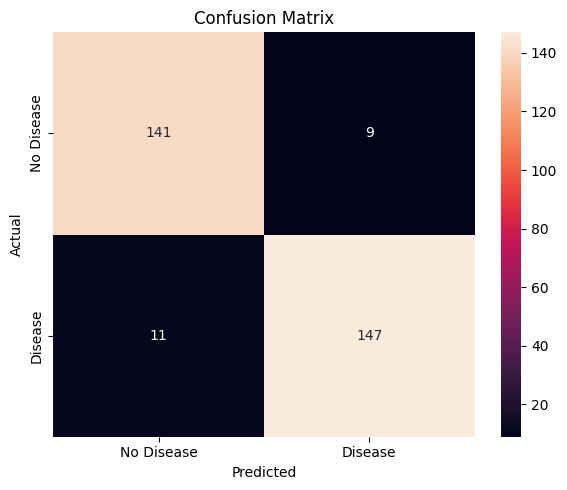

In [50]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Feature Importance

In [51]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values(
    'importance',
    ascending=False
)

print("Feature Importance Rankings:\n")

for i, row in enumerate(feature_importance.itertuples(), start=1):
    print(f"{i}. {row.feature}: {row.importance:.4f}")

Feature Importance Rankings:

1. cp: 0.1833
2. thal: 0.1366
3. ca: 0.1324
4. thalach: 0.1248
5. oldpeak: 0.1027
6. exang: 0.0807
7. age: 0.0772
8. trestbps: 0.0457
9. chol: 0.0394
10. slope: 0.0377
11. sex: 0.0263
12. restecg: 0.0091
13. fbs: 0.0041


### Feature Importance Graph

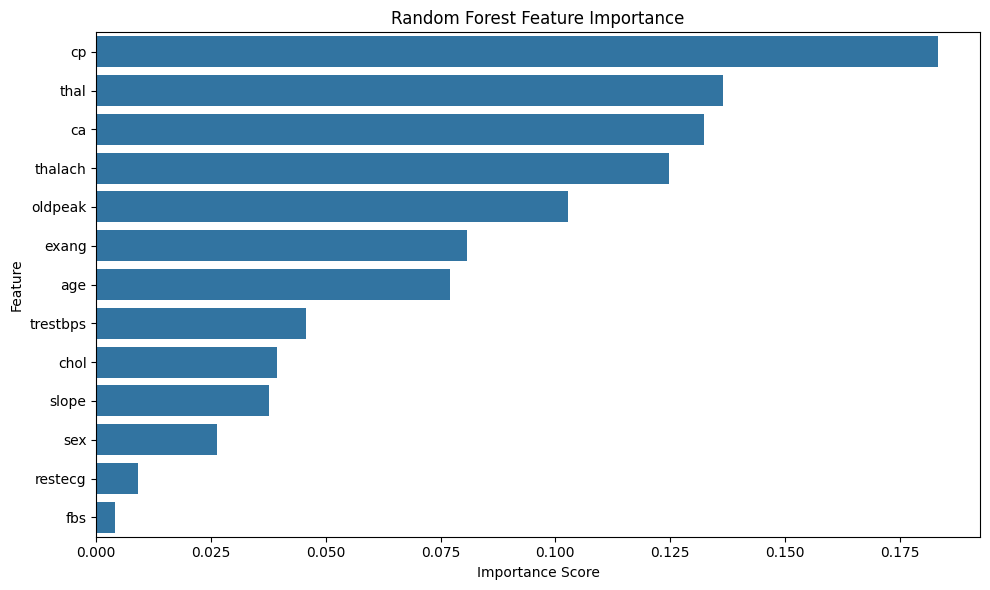

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='importance',
    y='feature'
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Model Save

In [53]:
model_folder = r"E:\Internship_Project\Heart_Disease_Classification\Heart_Disease\Model"

os.makedirs(model_folder, exist_ok=True)

model_path = os.path.join(model_folder, "heart_model.pkl")

joblib.dump(rf_classifier, model_path)

print("Model saved successfully!")
print("Model path:", model_path)
print("File exists:", os.path.exists(model_path))
print("File size:", os.path.getsize(model_path), "bytes")

Model saved successfully!
Model path: E:\Internship_Project\Heart_Disease_Classification\Heart_Disease\Model\heart_model.pkl
File exists: True
File size: 433753 bytes


### Saved Model Test

In [54]:
loaded_model = joblib.load(model_path)

print("Model loaded successfully!")

test_prediction = loaded_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_prediction)

print(f"Loaded Model Accuracy: {test_accuracy:.4f}")

Model loaded successfully!
Loaded Model Accuracy: 0.9351


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


### New Patient Prediction function

In [55]:
def predict_heart_disease(patient_data):
    patient_df = pd.DataFrame([patient_data])

    patient_df = patient_df[X.columns]

    prediction = loaded_model.predict(patient_df)[0]
    probability = loaded_model.predict_proba(patient_df)[0]

    return prediction, probability

### New Patient Test

In [56]:
new_patient = {
    'age': 57,
    'sex': 1,
    'cp': 0,
    'trestbps': 130,
    'chol': 250,
    'fbs': 0,
    'restecg': 1,
    'thalach': 150,
    'exang': 0,
    'oldpeak': 1.2,
    'slope': 1,
    'ca': 0,
    'thal': 2
}

prediction, probabilities = predict_heart_disease(new_patient)

print("New Patient Prediction:")

if prediction == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

print(f"Probability of No Disease: {probabilities[0]:.4f}")
print(f"Probability of Disease: {probabilities[1]:.4f}")
print(f"Confidence: {max(probabilities):.4f}")

New Patient Prediction:
Prediction: Heart Disease
Probability of No Disease: 0.3651
Probability of Disease: 0.6349
Confidence: 0.6349


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


### Final Summary 

In [57]:
print("=" * 50)
print("Random Forest Heart Disease Classification")
print("=" * 50)

print("\nDataset Summary:")
print(f"Total Samples: {len(df)}")
print(f"Features: {len(X.columns)}")
print(f"Heart Disease Cases: {y.sum()}")
print(f"No Disease Cases: {len(y) - y.sum()}")

print("\nModel Summary:")
print("Algorithm: Random Forest Classifier")
print(f"Number of Trees: {rf_classifier.n_estimators}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")

print("\nPerformance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

print("\nTop 3 Important Features:")

top_features = feature_importance.head(3)

for i, row in enumerate(top_features.itertuples(), start=1):
    print(f"{i}. {row.feature}: {row.importance:.4f}")

print("\nModel saved at:")
print(model_path)

print("=" * 50)

Random Forest Heart Disease Classification

Dataset Summary:
Total Samples: 1025
Features: 13
Heart Disease Cases: 526
No Disease Cases: 499

Model Summary:
Algorithm: Random Forest Classifier
Number of Trees: 100
Training Samples: 717
Testing Samples: 308

Performance Metrics:
Accuracy: 0.9351
Precision: 0.9423
Recall: 0.9304
F1-Score: 0.9363

Top 3 Important Features:
1. cp: 0.1833
2. thal: 0.1366
3. ca: 0.1324

Model saved at:
E:\Internship_Project\Heart_Disease_Classification\Heart_Disease\Model\heart_model.pkl
